In [127]:
#import Dependencies
import pandas as pd 
import numpy as np

In [128]:
#Data Collection

In [129]:
#Load dataset

In [130]:
df=pd.read_csv("Telco_Customer_Churn.csv")

In [131]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [132]:
df.shape

(7043, 21)

In [133]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [135]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [136]:
#Data Cleaning

In [137]:
#Remove unecessary columns

In [138]:
df=df.drop(['customerID'],axis=1)

In [139]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [140]:
#Exploring unique values in Categorical columns

In [141]:
features=["tenure","MonthlyCharges","TotalCharges"]
for col in df.columns:
    if col not in features: 
        print(col,df[col].unique())
        print("--"*50)

gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
----------------------------------------------------------------------------------------------------
SeniorCitizen [0 1]
----------------------------------------------------------------------------------------------------
Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------------------------------------------------------------------
Dependents <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------------------------------------------------------------------
PhoneService <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------------------------------------------------------------------
MultipleLines <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
----------------------------------------------------------------------------------------------------
InternetService <Arro

In [142]:
df.duplicated().sum()

np.int64(22)

In [143]:
#drop duplicate values

In [144]:
df=df.drop_duplicates(keep="first")

In [145]:
#After dropping duplicate values

In [146]:
df.duplicated().sum()

np.int64(0)

In [147]:
#Viewing TotalCharges Columns

In [148]:
df["TotalCharges"].values #the below values are in string/object format

<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 7021, dtype: str

In [149]:
#let see if total charges has how many blank spaces

In [150]:
len(df[df["TotalCharges"]==" "]) #there are total 11 blank spaces

11

In [151]:
#covert numeric string into numbers(float)

In [152]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") #errors="coerce" converts invalid columns into NAN

In [153]:
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7021, dtype: float64

In [154]:
len(df[df["TotalCharges"]==" "]) #now there are 0 blank spaces in our TotalCharges column

0

In [155]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [156]:
#Fill the Missing values

In [157]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [158]:
df.isnull().sum() #now there are 0 missing values 

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [159]:
#Check if any column has extra spaces

In [160]:
print(any(col!=col.strip() for col in df.columns))

False


In [161]:
#no extra space are present 

In [162]:
#Data Analysis & Visualization

In [163]:
#import dependencies that are needed for Data Visualization 

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
df["Churn"].value_counts() 

Churn
No     5164
Yes    1857
Name: count, dtype: int64

In [166]:
#Basic distribution analysis

In [167]:
#Churn distribution

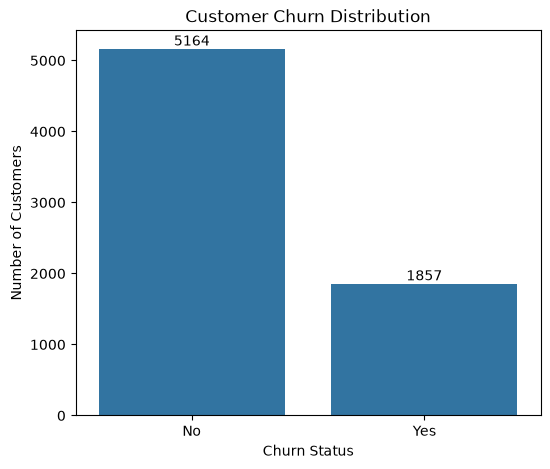

In [168]:
plt.figure(figsize=(6,5))
ax=sns.countplot(x="Churn",data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

In [169]:
#The above countplot graph represents Customer Churn Distribution #Here No means Customer who stayed with the company
                                                              #Yes means Customer who left the compamy  
#this is called imbalanced dataset 

In [170]:
#Gender Distribution

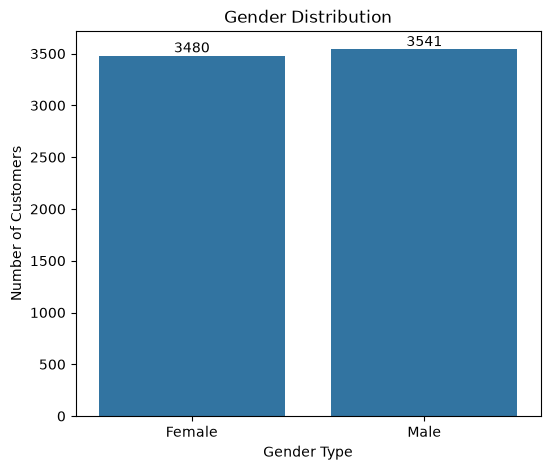

In [171]:
plt.figure(figsize=(6,5))
y=sns.countplot(x="gender",data=df)
for container in y.containers:
    y.bar_label(container)
plt.title("Gender Distribution")
plt.xlabel("Gender Type")
plt.ylabel("Number of Customers")
plt.show()

In [172]:
#The above countplot graph represents Gender Distribution here there are total 3480 Female Customers
                                                              #there are total 3541 Male Customers  
#As we can observe that Female and Male Customers are mostly equal

In [173]:
#SeniorCitizen Distribution

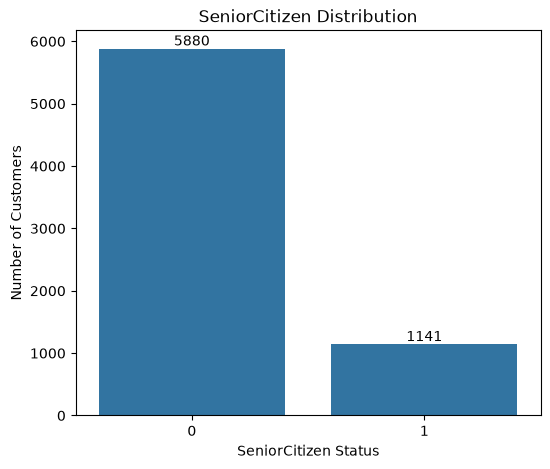

In [174]:
plt.figure(figsize=(6,5))
y=sns.countplot(x="SeniorCitizen",data=df)
for container in y.containers:
    y.bar_label(container)
plt.title("SeniorCitizen Distribution")
plt.xlabel("SeniorCitizen Status")
plt.ylabel("Number of Customers")
plt.show()

In [175]:
#the above countplot graph reperesnt SeniorCitizen Distribution here 0 means Not a Senior Citizen
                                                                     #1 means Senior Citizen 

In [176]:
#After analysing important features

In [177]:
#These features were selected because they have a strong impact on customer churn

In [178]:
#Contract Vs Churn #compare contract column with target column(Churn)

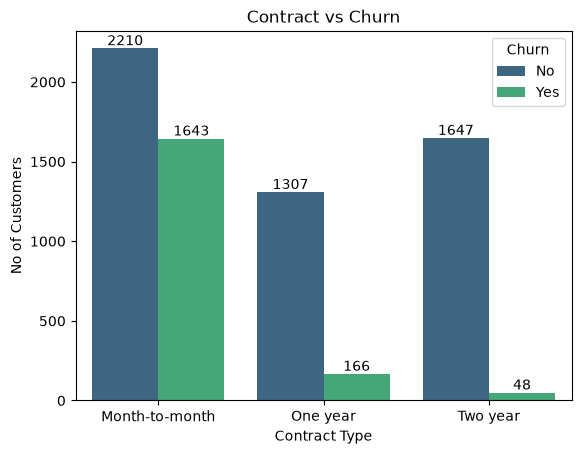

In [179]:
a=sns.countplot(x="Contract",hue="Churn",palette="viridis",data=df)
for container in a.containers:
    a.bar_label(container)
plt.title("Contract vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("No of Customers")
plt.show()

In [180]:
#The above countplot graph Compares Contract Vs Churn 
#there are total Three types of contract Month-to-month,One year,Two year
#as we can observe Month-to month Contract has Very high churn and are more likely to leave the company

In [181]:
#Internet Service Vs Churn

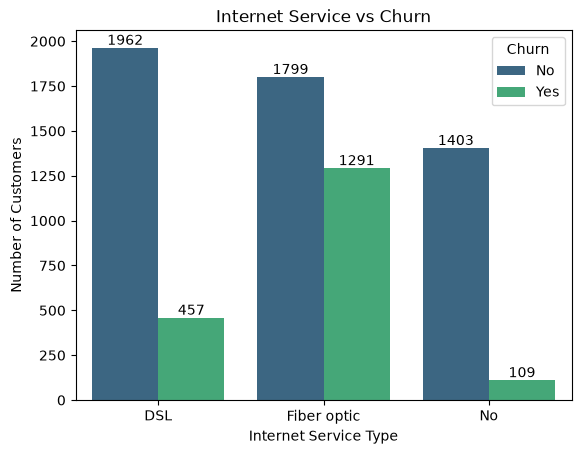

In [182]:
b=sns.countplot(x="InternetService",hue="Churn",palette="viridis",data=df)
for container in b.containers:
    b.bar_label(container)
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.show()

In [183]:
#The above countplot Compares Internet Service vs Churn there are mainly three types of Internet Service 
#DSL,Fiber optic,No(No internet)
#Fiber Optic customers leave much more than DSL and No internet Customers

In [184]:
#Tech Support Vs Churn

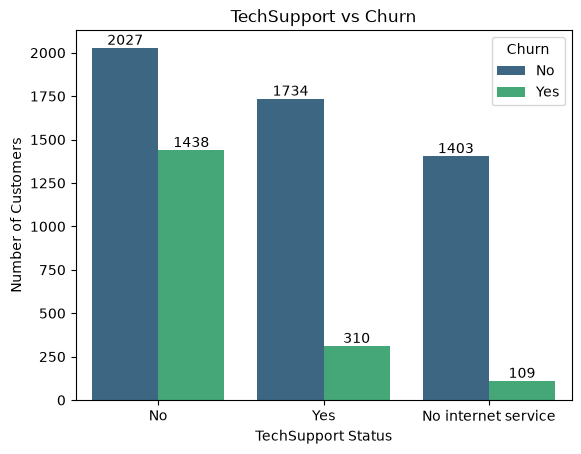

In [185]:
c=sns.countplot(x="TechSupport",hue="Churn",palette="viridis",data=df)
for container in c.containers:
    c.bar_label(container)
plt.title("TechSupport vs Churn")
plt.xlabel("TechSupport Status")
plt.ylabel("Number of Customers")
plt.show()

In [186]:
#The above countplot graph Compares TechSupport vs Churn i.e
#No,Yes,No internet service
#Customers without Techsupport are more likely to leave 

In [187]:
#Online Security Vs Churn

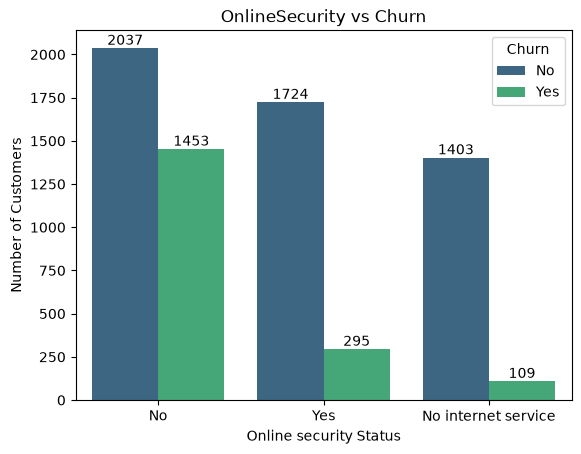

In [188]:
d=sns.countplot(x="OnlineSecurity",hue="Churn",palette="viridis",data=df)
for container in d.containers:
    d.bar_label(container)
plt.title("OnlineSecurity vs Churn")
plt.xlabel("Online security Status")
plt.ylabel("Number of Customers")
plt.show()

In [189]:
#The above countplot graph Compares Online Security vs Churn i.e
#No,Yes,No internet service
#Customers without Online Security Status leave much more often 

In [190]:
#PaymentMethod Vs Churn

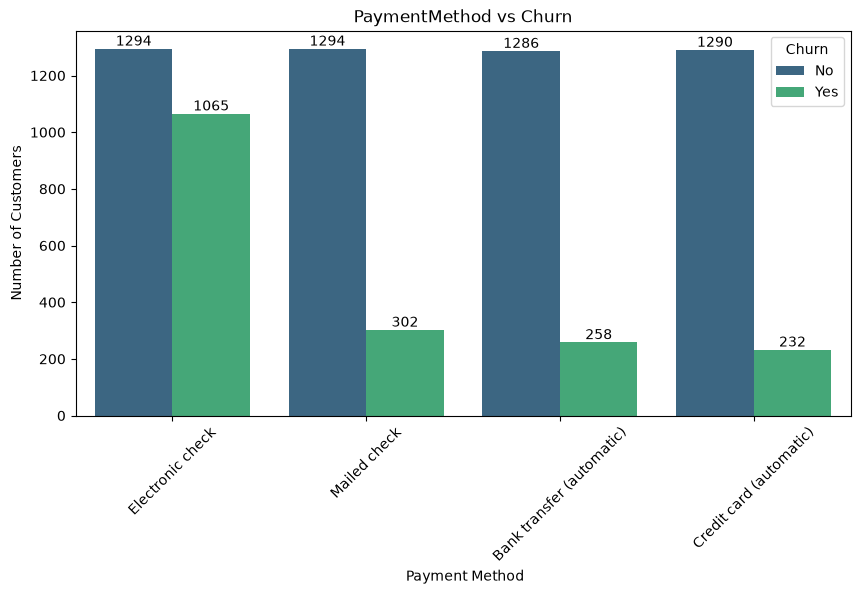

In [191]:
plt.figure(figsize=(10,5))
e=sns.countplot(x="PaymentMethod",hue="Churn",palette="viridis",data=df)
for container in e.containers:
    e.bar_label(container)
plt.title("PaymentMethod vs Churn")
plt.xlabel(" Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [192]:
#the above countplot graph Compares PaymentMethod vs Churn there are mainly four types of Payment Method
#i.e Electronic check,Mailed check,Bank transfer(automatic),Credit card(automatic)
#As we can observe the Customers with Electronic check payment method leaves more 
#Automatic payment customers leave less as compared to other payment method

In [193]:
#MonthlyCharges vs Churn

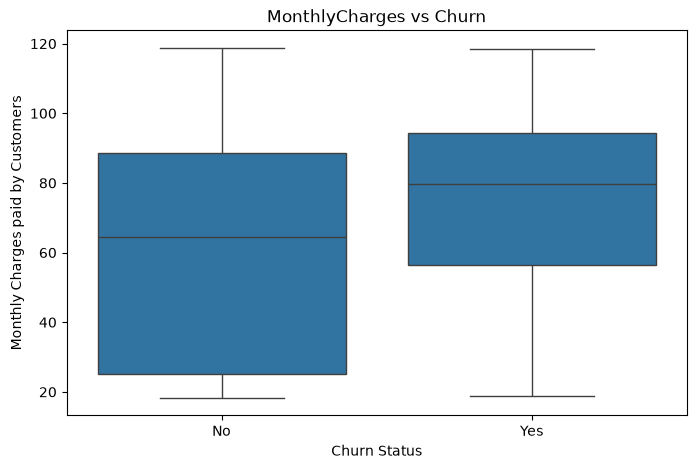

In [194]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("MonthlyCharges vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges paid by Customers")
plt.show()

In [195]:
#the above boxplot Compares MonthlyCharges Vs Churn Status 
#as we can see Customers with higher monthly charges are more likely to churn

In [196]:
#TotalCharges Vs Churn

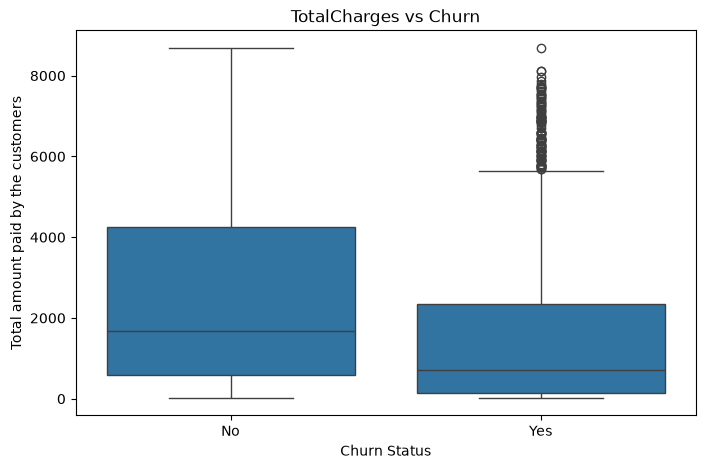

In [197]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn",y="TotalCharges",data=df)
plt.title("TotalCharges vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Total amount paid by the customers")
plt.show()

In [198]:
#The above boxplot graph Compares TotalCharges Vs Churn 
#As we can see the Customers with Higher total Charges stays with the company
#the Customers with Lower total Charges leaves early
#Outliers are present

In [199]:
#Tenure vs Churn

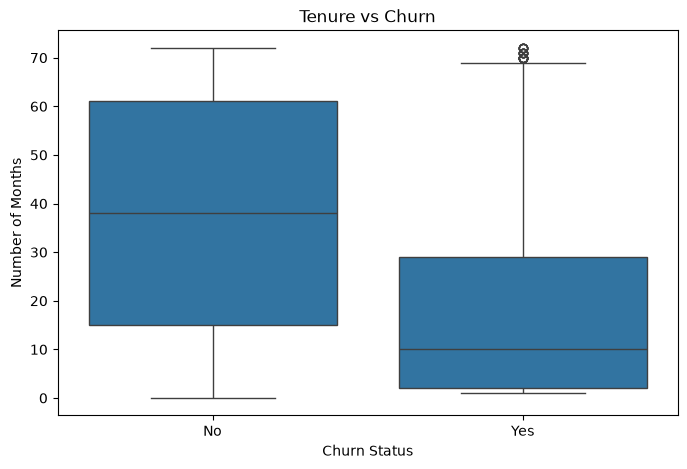

In [200]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Months")
plt.show()

In [201]:
#The above boxplot graph compares Tenure vs Churn
#Here we can see Customer who didnot churn have higher tenure
#And the Customer who Churned generally have no tenure
#outliers are also present (outliers near 70+months)

In [202]:
#One hot Encoding

In [203]:
#Cleaning Categorical columns for consistency

In [204]:
# Replacing 'No phone service' -> NO
# Replacing 'No internet Service' -> No
df['MultipleLines']=df['MultipleLines'].replace('No phone service','No')
df['OnlineSecurity']=df['OnlineSecurity'].replace('No internet service','No')
df['OnlineBackup']=df['OnlineBackup'].replace('No internet service','No')
df['DeviceProtection']=df['DeviceProtection'].replace('No internet service','No')
df['TechSupport']=df['TechSupport'].replace('No internet service','No')
df['StreamingTV']=df['StreamingTV'].replace('No internet service','No')
df['StreamingMovies']=df['StreamingMovies'].replace('No internet service','No')

In [205]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4386,Male,0,Yes,Yes,55,Yes,No,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Bank transfer (automatic),57.55,3046.40,Yes
3821,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.20,74.20,Yes
1066,Male,0,Yes,No,47,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,19.65,973.10,No
4377,Female,0,Yes,No,22,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),80.00,1706.45,No
4850,Female,0,No,No,54,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,One year,Yes,Credit card (automatic),100.05,5299.65,No


In [206]:
#Covert Yes or No coulumns into 1 and 0

In [207]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df[col]=df[col].replace({'Yes': 1,'No': 0})

In [208]:
#Convert gender column into 1 and 0 here Female=1 and Male=0

In [209]:
df['gender']=df['gender'].replace({'Female':1,'Male':0})

In [210]:
#After converting gender column into 1 and 0

In [211]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [212]:
#Encoding Categorical Variables using One-Hot Encoding 

In [213]:
df=pd.get_dummies(df,columns=['InternetService','Contract','PaymentMethod'],drop_first=True,dtype=int)

In [214]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


In [215]:
df.dtypes

gender                                    object
SeniorCitizen                              int64
Partner                                   object
Dependents                                object
tenure                                     int64
PhoneService                              object
MultipleLines                             object
OnlineSecurity                            object
OnlineBackup                              object
DeviceProtection                          object
TechSupport                               object
StreamingTV                               object
StreamingMovies                           object
PaperlessBilling                          object
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                     object
InternetService_Fiber optic                int64
InternetService_No                         int64
Contract_One year                          int64
Contract_Two year   

In [216]:
df.shape

(7021, 24)

In [219]:
#The correlation heatmap shows that customers who stay longer generally accumulate higher total charges
#Customers with higher monthly charges also tend to have higher total charges
#Fiber optic users tend to have higher monthly charges
#customers without internet service generally have lower monthly charges

In [220]:
#split features and targets
x=df.drop("Churn",axis=1)
y=df["Churn"]

In [221]:
x.shape

(7021, 23)

In [222]:
y.shape

(7021,)

In [257]:
import pickle
feature_columns = x.columns.tolist()
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)
print("Feature columns saved successfully!")

Feature columns saved successfully!


In [233]:
y = y.astype(int)

In [288]:
#split 20% for testing and 80% foe training
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,#20%
    random_state=42
)   

In [300]:
x_train.shape

(5616, 23)

In [301]:
y_train.shape

(5616,)

In [302]:
x_test.shape

(1405, 23)

In [303]:
y_test.shape

(1405,)

In [304]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    random_state=42,
)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [305]:
# Make predictions
y_pred = model.predict(x_test)
print(y_pred)

[1 0 0 ... 0 0 0]


In [306]:
#accuracy and classification report
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.801423487544484
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1053
           1       0.63      0.51      0.56       352

    accuracy                           0.80      1405
   macro avg       0.74      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



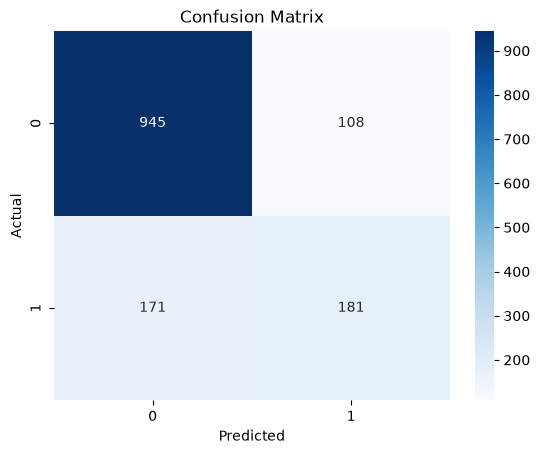

In [277]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [278]:
#TN - Correctly predicted customer will stay
#TP - Correctly predicted customer will leave
#FP - Predicted leave, but customer actually stays
#FN - Predicted stay, but customer actually leaves

In [280]:
with open("churn_model.pkl", "wb") as f:
    pickle.dump(model, f)